# Simple decision tree from scratch

This notebook implements a compact binary decision tree classifier without using `scikit-learn` tree functions.

Included here:
- entropy and information gain functions
- greedy split selection
- one feature used at most once along a branch
- tree plotting with feature, threshold, and IG
- class purity / error report
- built-in Iris demo
- optional prediction on a second unlabeled CSV

## User parameters
Edit the parameter cell below.

For a quick test, leave `RUN_IRIS_DEMO = True`.
For your own data, set `RUN_IRIS_DEMO = False` and set `CSV_PATH`.

To score a second unlabeled CSV, set `PREDICT_CSV_PATH`.


=== DATA SUMMARY ===
Number of samples : 150
Number of features: 4
Label column      : target

=== FEATURE INFORMATION GAIN USED IN THE TREE ===
 split_number           feature  information_gain
            1 petal length (cm)          0.918296
            2  petal width (cm)          0.690160
            3 sepal length (cm)          0.066194
            4 sepal length (cm)          0.061060

=== CLASS PURITY REPORT (ON THE PROVIDED DATA) ===
     class  n_samples  purity  error_fraction
    setosa         50    1.00            0.00
versicolor         50    0.98            0.02
 virginica         50    0.92            0.08

=== OVERALL TRAINING ACCURACY ON THE PROVIDED DATA ===
Accuracy = 0.9667

=== HOW TO PREDICT NEW SAMPLES ===
Example single row (all missing here just as a placeholder):
x_new = [nan nan nan nan]
predict_one(tree, x_new) -> setosa

Example batch prediction:
predict(tree, X_new) -> ['setosa' 'setosa']


/var/folders/tr/k1lq43vx4znbc8dfkdxfjj4h0000gp/T/ipykernel_67874/3342705314.py:387: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


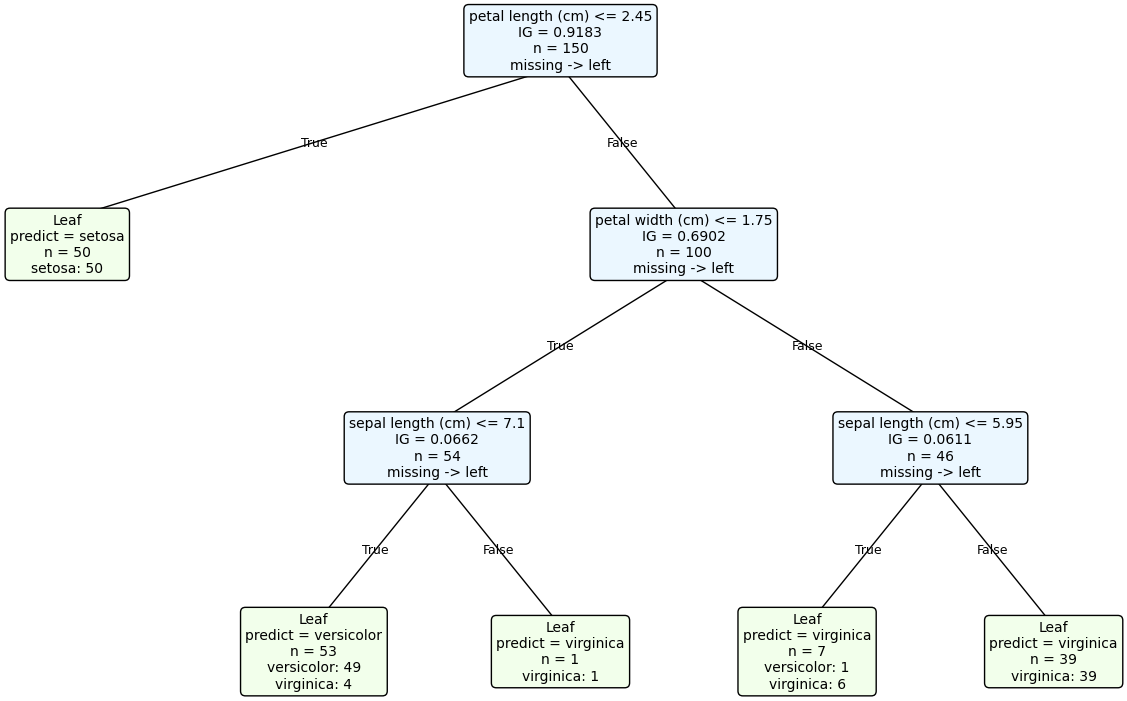

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from collections import Counter
from typing import Optional, Dict, List, Tuple

# ============================================================
# USER PARAMETERS
# ============================================================
CSV_PATH = "your_data.csv"              # Training CSV. Last column must be the label.
PREDICT_CSV_PATH = None                 # Optional unlabeled CSV to score. Same feature columns/order as training CSV.
OUTPUT_PREDICTIONS_CSV = "predictions_output.csv"

MAX_DEPTH = 3                           # Maximum tree depth.
MIN_SAMPLES_SPLIT = 2                   # Stop if a node has fewer samples.
PLOT_DEPTH = 3                          # Depth to show in the tree plot.
MISSING_DIRECTION = "best"              # "best", "left", or "right"

RUN_IRIS_DEMO = True                   # If True, ignore CSV_PATH and create/test on sklearn Iris.
IRIS_OUTPUT_CSV = "iris_demo_with_labels.csv"
RANDOM_STATE = 0

# ============================================================
# DATA STRUCTURES
# ============================================================
@dataclass
class TreeNode:
    """A single node in the binary decision tree."""
    depth: int
    n_samples: int
    class_counts: Dict[str, int]
    predicted_class: str
    entropy: float
    feature: Optional[str] = None
    feature_index: Optional[int] = None
    threshold: Optional[float] = None
    info_gain: float = 0.0
    missing_go_to_left: bool = True
    left: Optional["TreeNode"] = None
    right: Optional["TreeNode"] = None
    is_leaf: bool = True


# ============================================================
# BASIC HELPER FUNCTIONS
# ============================================================
def entropy_from_counts(counts: np.ndarray) -> float:
    """Compute Shannon entropy from class counts."""
    total = counts.sum()
    if total == 0:
        return 0.0
    probs = counts[counts > 0] / total
    return float(-np.sum(probs * np.log2(probs)))


def entropy(y: np.ndarray) -> float:
    """Entropy of a label vector."""
    _, counts = np.unique(y, return_counts=True)
    return entropy_from_counts(counts)


def information_gain(y_parent: np.ndarray, y_left: np.ndarray, y_right: np.ndarray) -> float:
    """Information gain of a split."""
    n = len(y_parent)
    if n == 0 or len(y_left) == 0 or len(y_right) == 0:
        return 0.0
    h_parent = entropy(y_parent)
    h_left = entropy(y_left)
    h_right = entropy(y_right)
    weighted_child_entropy = (len(y_left) / n) * h_left + (len(y_right) / n) * h_right
    return float(h_parent - weighted_child_entropy)


def majority_class(y: np.ndarray) -> str:
    """Return the most common class label."""
    values, counts = np.unique(y, return_counts=True)
    return str(values[np.argmax(counts)])


def class_count_dict(y: np.ndarray) -> Dict[str, int]:
    """Class counts as a regular dictionary for display."""
    return dict(sorted(Counter(y).items(), key=lambda kv: str(kv[0])))


# ============================================================
# SPLIT SEARCH
# ============================================================
def candidate_thresholds(x: np.ndarray) -> np.ndarray:
    """Midpoints between sorted unique non-missing values."""
    x_valid = x[~np.isnan(x)]
    unique_vals = np.unique(x_valid)
    if len(unique_vals) < 2:
        return np.array([])
    return (unique_vals[:-1] + unique_vals[1:]) / 2.0


def evaluate_best_split_for_feature(
    X: np.ndarray,
    y: np.ndarray,
    feature_index: int,
    feature_name: str,
    missing_direction: str = "best",
) -> Optional[Dict]:
    """Find the best threshold for a single numeric feature."""
    x = X[:, feature_index].astype(float)
    thresholds = candidate_thresholds(x)
    if len(thresholds) == 0:
        return None

    best = None
    missing_mask = np.isnan(x)
    valid_mask = ~missing_mask

    for threshold in thresholds:
        left_valid = valid_mask & (x <= threshold)
        right_valid = valid_mask & (x > threshold)

        if left_valid.sum() == 0 or right_valid.sum() == 0:
            continue

        if missing_direction == "left":
            left_mask = left_valid | missing_mask
            right_mask = right_valid
            ig = information_gain(y, y[left_mask], y[right_mask])
            send_left = True
        elif missing_direction == "right":
            left_mask = left_valid
            right_mask = right_valid | missing_mask
            ig = information_gain(y, y[left_mask], y[right_mask])
            send_left = False
        else:
            left_mask_a = left_valid | missing_mask
            right_mask_a = right_valid
            ig_a = information_gain(y, y[left_mask_a], y[right_mask_a])

            left_mask_b = left_valid
            right_mask_b = right_valid | missing_mask
            ig_b = information_gain(y, y[left_mask_b], y[right_mask_b])

            if ig_a >= ig_b:
                left_mask, right_mask, ig, send_left = left_mask_a, right_mask_a, ig_a, True
            else:
                left_mask, right_mask, ig, send_left = left_mask_b, right_mask_b, ig_b, False

        if len(y[left_mask]) == 0 or len(y[right_mask]) == 0:
            continue

        split_info = {
            "feature": feature_name,
            "feature_index": feature_index,
            "threshold": float(threshold),
            "info_gain": float(ig),
            "missing_go_to_left": send_left,
            "left_mask": left_mask,
            "right_mask": right_mask,
        }

        if best is None or split_info["info_gain"] > best["info_gain"]:
            best = split_info

    return best


def find_best_split(
    X: np.ndarray,
    y: np.ndarray,
    feature_names: List[str],
    available_features: List[int],
    missing_direction: str = "best",
) -> Optional[Dict]:
    """Search all still-available features and return the split with the largest IG."""
    best_overall = None
    for j in available_features:
        result = evaluate_best_split_for_feature(X, y, j, feature_names[j], missing_direction)
        if result is None:
            continue
        if best_overall is None or result["info_gain"] > best_overall["info_gain"]:
            best_overall = result
    return best_overall


# ============================================================
# TREE BUILDING
# ============================================================
def build_tree(
    X: np.ndarray,
    y: np.ndarray,
    feature_names: List[str],
    available_features: List[int],
    depth: int,
    max_depth: int,
    min_samples_split: int,
    missing_direction: str,
    used_feature_ig: List[Tuple[str, float]],
) -> TreeNode:
    """Recursively build the tree.

    A chosen feature is removed for all descendants of that node, so a feature is used
    at most once along a branch.
    """
    node = TreeNode(
        depth=depth,
        n_samples=len(y),
        class_counts=class_count_dict(y),
        predicted_class=majority_class(y),
        entropy=entropy(y),
    )

    pure_node = len(np.unique(y)) == 1
    no_features_left = len(available_features) == 0
    max_depth_reached = depth >= max_depth
    too_few_samples = len(y) < min_samples_split

    if pure_node or no_features_left or max_depth_reached or too_few_samples:
        return node

    best_split = find_best_split(X, y, feature_names, available_features, missing_direction)
    if best_split is None or best_split["info_gain"] <= 0:
        return node

    node.is_leaf = False
    node.feature = best_split["feature"]
    node.feature_index = best_split["feature_index"]
    node.threshold = best_split["threshold"]
    node.info_gain = best_split["info_gain"]
    node.missing_go_to_left = best_split["missing_go_to_left"]
    used_feature_ig.append((node.feature, node.info_gain))

    left_mask = best_split["left_mask"]
    right_mask = best_split["right_mask"]
    remaining_features = [f for f in available_features if f != node.feature_index]

    node.left = build_tree(
        X[left_mask], y[left_mask], feature_names, remaining_features,
        depth + 1, max_depth, min_samples_split, missing_direction, used_feature_ig
    )
    node.right = build_tree(
        X[right_mask], y[right_mask], feature_names, remaining_features,
        depth + 1, max_depth, min_samples_split, missing_direction, used_feature_ig
    )
    return node


# ============================================================
# PREDICTION
# ============================================================
def predict_one(node: TreeNode, x: np.ndarray) -> str:
    """Predict a single sample."""
    current = node
    while not current.is_leaf:
        value = x[current.feature_index]
        if np.isnan(value):
            current = current.left if current.missing_go_to_left else current.right
        elif value <= current.threshold:
            current = current.left
        else:
            current = current.right
    return current.predicted_class


def predict(node: TreeNode, X: np.ndarray) -> np.ndarray:
    """Predict labels for all rows."""
    return np.array([predict_one(node, row) for row in X], dtype=object)


def predict_from_dataframe(node: TreeNode, df_features: pd.DataFrame) -> np.ndarray:
    """Predict from a feature-only DataFrame."""
    X = df_features.apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
    return predict(node, X)


# ============================================================
# REPORTING
# ============================================================
def summarize_used_feature_ig(used_feature_ig: List[Tuple[str, float]]) -> pd.DataFrame:
    """One row per split in the order the tree was built."""
    if not used_feature_ig:
        return pd.DataFrame(columns=["split_number", "feature", "information_gain"])
    rows = [{"split_number": i + 1, "feature": f, "information_gain": ig}
            for i, (f, ig) in enumerate(used_feature_ig)]
    return pd.DataFrame(rows)


def class_purity_report(y_true: np.ndarray, y_pred: np.ndarray) -> pd.DataFrame:
    """Purity and error fraction per true class."""
    classes = np.unique(y_true)
    rows = []
    for cls in classes:
        mask = (y_true == cls)
        n = int(mask.sum())
        correct = int(np.sum(y_pred[mask] == y_true[mask]))
        purity = correct / n if n > 0 else np.nan
        rows.append({
            "class": cls,
            "n_samples": n,
            "purity": float(purity),
            "error_fraction": float(1.0 - purity),
        })
    return pd.DataFrame(rows)


# ============================================================
# TREE PLOTTING
# ============================================================
def count_visible_positions(node: TreeNode, max_depth_to_plot: int) -> int:
    """Count leaf-like positions needed for layout."""
    if node is None:
        return 0
    if node.is_leaf or node.depth >= max_depth_to_plot:
        return 1
    return count_visible_positions(node.left, max_depth_to_plot) + count_visible_positions(node.right, max_depth_to_plot)


def node_label(node: TreeNode, max_depth_to_plot: int) -> str:
    """Text shown inside a plotted node."""
    if node.is_leaf or node.depth >= max_depth_to_plot:
        counts_text = "\n".join([f"{k}: {v}" for k, v in node.class_counts.items()])
        return f"Leaf\npredict = {node.predicted_class}\nn = {node.n_samples}\n{counts_text}"
    missing_side = "left" if node.missing_go_to_left else "right"
    return f"{node.feature} <= {node.threshold:.3g}\nIG = {node.info_gain:.4f}\nn = {node.n_samples}\nmissing -> {missing_side}"


def assign_plot_positions(
    node: TreeNode,
    max_depth_to_plot: int,
    x_left: float,
    x_right: float,
    y_step: float,
    positions: Dict[int, Tuple[float, float]],
):
    """Assign x,y positions recursively."""
    if node is None:
        return
    x_mid = 0.5 * (x_left + x_right)
    y = -node.depth * y_step
    positions[id(node)] = (x_mid, y)

    if node.is_leaf or node.depth >= max_depth_to_plot:
        return

    left_slots = count_visible_positions(node.left, max_depth_to_plot)
    right_slots = count_visible_positions(node.right, max_depth_to_plot)
    total_slots = left_slots + right_slots
    split_x = x_left + (x_right - x_left) * (left_slots / total_slots)

    assign_plot_positions(node.left, max_depth_to_plot, x_left, split_x, y_step, positions)
    assign_plot_positions(node.right, max_depth_to_plot, split_x, x_right, y_step, positions)


def draw_tree(node: TreeNode, max_depth_to_plot: int = 3, figsize: Tuple[int, int] = (14, 8)):
    """Plot the tree to a chosen depth using matplotlib."""
    positions = {}
    total_width = count_visible_positions(node, max_depth_to_plot)
    assign_plot_positions(node, max_depth_to_plot, 0, total_width, 1.6, positions)

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_axis_off()

    def _draw(current: TreeNode):
        if current is None:
            return
        x, y = positions[id(current)]
        text = node_label(current, max_depth_to_plot)
        is_visible_leaf = current.is_leaf or current.depth >= max_depth_to_plot
        box_style = dict(
            boxstyle="round,pad=0.35",
            fc=(0.92, 0.97, 1.0) if not is_visible_leaf else (0.95, 1.0, 0.92),
            ec="black",
        )
        ax.text(x, y, text, ha="center", va="center", fontsize=10, bbox=box_style)

        if is_visible_leaf:
            return

        for child, edge_text in [(current.left, "True"), (current.right, "False")]:
            if child is None:
                continue
            x2, y2 = positions[id(child)]
            ax.plot([x, x2], [y - 0.2, y2 + 0.2], color="black", lw=1)
            ax.text((x + x2) / 2, (y + y2) / 2, edge_text, fontsize=9, ha="center", va="center")
            _draw(child)

    _draw(node)
    #ax.set_title(f"Decision tree (shown to depth = {max_depth_to_plot})")
    plt.tight_layout()
    plt.show()


# ============================================================
# DATA LOADING / SAVING
# ============================================================
def load_csv_dataset(csv_path: str) -> Tuple[np.ndarray, np.ndarray, List[str], str]:
    """Load CSV. Last column is the label."""
    df = pd.read_csv(csv_path, na_values=["", "NA", "NaN", "nan", "None", "?"])
    if df.shape[1] < 2:
        raise ValueError("CSV must contain at least one feature column and one label column.")
    feature_names = list(df.columns[:-1])
    label_name = df.columns[-1]
    X_df = df.iloc[:, :-1].apply(pd.to_numeric, errors="coerce")
    y = df.iloc[:, -1].astype(str).to_numpy()
    X = X_df.to_numpy(dtype=float)
    return X, y, feature_names, label_name


def load_feature_only_csv(csv_path: str, expected_feature_names: List[str]) -> pd.DataFrame:
    """Load an unlabeled CSV and reorder/check feature columns."""
    df = pd.read_csv(csv_path, na_values=["", "NA", "NaN", "nan", "None", "?"])
    missing_cols = [c for c in expected_feature_names if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Prediction CSV is missing required feature columns: {missing_cols}")
    return df.loc[:, expected_feature_names].copy()


def save_predictions_csv(input_df: pd.DataFrame, predicted_labels: np.ndarray, output_csv_path: str, label_name: str = "predicted_label"):
    """Save original rows plus predicted labels."""
    out = input_df.copy()
    out[label_name] = predicted_labels
    out.to_csv(output_csv_path, index=False)


def make_iris_demo_csv(output_csv_path: str = IRIS_OUTPUT_CSV) -> str:
    """Create a labeled Iris CSV using scikit-learn."""
    try:
        from sklearn.datasets import load_iris
    except ImportError as exc:
        raise ImportError("scikit-learn is required for RUN_IRIS_DEMO=True.") from exc

    iris = load_iris(as_frame=True)
    df = iris.frame.copy()
    label_map = {i: name for i, name in enumerate(iris.target_names)}
    df["target"] = df["target"].map(label_map)
    df.to_csv(output_csv_path, index=False)
    return output_csv_path


# ============================================================
# CONVENIENCE WRAPPERS
# ============================================================
def train_tree_from_csv(csv_path: str):
    """Train a tree from a labeled CSV and return useful objects."""
    X, y, feature_names, label_name = load_csv_dataset(csv_path)

    used_feature_ig: List[Tuple[str, float]] = []
    tree = build_tree(
        X=X,
        y=y,
        feature_names=feature_names,
        available_features=list(range(X.shape[1])),
        depth=0,
        max_depth=MAX_DEPTH,
        min_samples_split=MIN_SAMPLES_SPLIT,
        missing_direction=MISSING_DIRECTION,
        used_feature_ig=used_feature_ig,
    )
    return tree, X, y, feature_names, label_name, used_feature_ig


def report_training_results(tree: TreeNode, X: np.ndarray, y: np.ndarray, label_name: str, used_feature_ig: List[Tuple[str, float]]):
    """Print split IG table, class purity table, and accuracy."""
    y_pred = predict(tree, X)
    accuracy = float(np.mean(y_pred == y))

    print("\n=== DATA SUMMARY ===")
    print(f"Number of samples : {len(y)}")
    print(f"Number of features: {X.shape[1]}")
    print(f"Label column      : {label_name}")

    print("\n=== FEATURE INFORMATION GAIN USED IN THE TREE ===")
    ig_table = summarize_used_feature_ig(used_feature_ig)
    if len(ig_table) == 0:
        print("No splits were made.")
    else:
        print(ig_table.to_string(index=False))

    print("\n=== CLASS PURITY REPORT (ON THE PROVIDED DATA) ===")
    purity_table = class_purity_report(y, y_pred)
    print(purity_table.to_string(index=False))

    print("\n=== OVERALL TRAINING ACCURACY ON THE PROVIDED DATA ===")
    print(f"Accuracy = {accuracy:.4f}")


def demo_predict_new_samples(tree: TreeNode, feature_names: List[str]):
    """Small example showing how to predict one or many rows."""
    print("\n=== HOW TO PREDICT NEW SAMPLES ===")
    x_new = np.full(len(feature_names), np.nan, dtype=float)
    print("Example single row (all missing here just as a placeholder):")
    print("x_new =", x_new)
    print("predict_one(tree, x_new) ->", predict_one(tree, x_new))

    X_new = np.vstack([x_new, x_new])
    print("\nExample batch prediction:")
    print("predict(tree, X_new) ->", predict(tree, X_new))


def maybe_score_unlabeled_csv(tree: TreeNode, feature_names: List[str]):
    """If requested, score a second CSV and write predictions out."""
    if not PREDICT_CSV_PATH:
        return
    predict_df = load_feature_only_csv(PREDICT_CSV_PATH, feature_names)
    predicted = predict_from_dataframe(tree, predict_df)
    save_predictions_csv(predict_df, predicted, OUTPUT_PREDICTIONS_CSV)
    print("\n=== PREDICTION CSV WRITTEN ===")
    print(f"Input unlabeled CSV : {PREDICT_CSV_PATH}")
    print(f"Output predictions  : {OUTPUT_PREDICTIONS_CSV}")


# ============================================================
# MAIN PROGRAM
# ============================================================
def main():
    csv_path = make_iris_demo_csv(IRIS_OUTPUT_CSV) if RUN_IRIS_DEMO else CSV_PATH
    if not os.path.exists(csv_path):
        raise FileNotFoundError(
            f"Could not find '{csv_path}'. Edit CSV_PATH or set RUN_IRIS_DEMO=True."
        )

    tree, X, y, feature_names, label_name, used_feature_ig = train_tree_from_csv(csv_path)
    report_training_results(tree, X, y, label_name, used_feature_ig)
    demo_predict_new_samples(tree, feature_names)
    maybe_score_unlabeled_csv(tree, feature_names)
    draw_tree(tree, max_depth_to_plot=PLOT_DEPTH)


if __name__ == "__main__":
    main()


In [ ]:
What’s included:

binary tree built from scratch
greedy split choice by maximizing information gain
separate entropy and information gain functions
numeric features with missing values handled
stop at max depth or when no valid split remains
user-parameter block at the top
tree plotting to user-specified depth
split labels showing feature, threshold, and IG
leaf labels showing class counts
report of IG for each split used in the tree
per-class purity and error fraction on the provided data

One implementation detail to note:

the code uses each feature at most once along a branch, which is the usual ID3-style behavior in recursive trees.

## Recommended first test
Set `RUN_IRIS_DEMO = True` in the parameter block above, then run the next cell.

In [ ]:
RUN_IRIS_DEMO = True
CSV_PATH = "your_data.csv"
PREDICT_CSV_PATH = None
MAX_DEPTH = 3
PLOT_DEPTH = 3
main()

## How to predict one new sample
The order of values must match the feature order used in training.

In [ ]:
csv_path = make_iris_demo_csv()
tree, X, y, feature_names, label_name, used_feature_ig = train_tree_from_csv(csv_path)
print(feature_names)

x_new = np.array([5.1, 3.5, 1.4, 0.2], dtype=float)
print("Predicted label:", predict_one(tree, x_new))

## How to predict many new samples

In [ ]:
X_new = np.array([
    [5.1, 3.5, 1.4, 0.2],
    [6.7, 3.1, 4.7, 1.5],
    [7.2, np.nan, 6.0, 1.8],
], dtype=float)

print(predict(tree, X_new))

## How to score a second unlabeled CSV and save predictions
Your prediction CSV must contain the same feature column names as the training data.

In [ ]:
# Example:
# PREDICT_CSV_PATH = "new_samples.csv"
# OUTPUT_PREDICTIONS_CSV = "new_samples_with_predictions.csv"
# RUN_IRIS_DEMO = False
# CSV_PATH = "your_training_data.csv"
# main()
pass